In [90]:
import json
import pandas as pd
from src.lift2Dto3D import load_camera_para_from_json,cameraPara
import cv2
json_data = '/home/qichen/headbar/data/headbarDual/lifting_out.json'
with open(json_data, 'r') as f:
    saved = json.load(f)
data = saved['lifter_outs']
cam_params_paths = saved['cam_params']
cam_params = {}
for k,v in cam_params_paths.items():
    cam_params[k] = load_camera_para_from_json(v)

df_list = []
for record in data:
    if record is None or (isinstance(record, dict) and len(record) == 1 and list(record.values())[0] is None):
        continue  # 跳过无效记录
    if isinstance(record, dict):
        new_record = {}
        for key, value in record.items():
            if isinstance(value, list):
                for i, v in enumerate(value):
                    if isinstance(v, list) and len(v) == 1:
                        new_record[f"{key}_{i}"] = v[0]
                    else:
                        new_record[f"{key}_{i}"] = v
            else:
                new_record[key] = value
        df_list.append(new_record)

df = pd.DataFrame(df_list)

In [91]:
df.head()

,v_0,v_1,v_2,p_0,p_1,p_2,p_3,middle_0,middle_1,middle_2,side1127_0,side1127_1,top1127_0,top1127_1,side1127_middle_0,side1127_middle_1,top1127_middle_0,top1127_middle_1
0,0.344247,0.271850,0.898661,0.346702,0.310727,0.885012,0.000317,0.316056,107.169508,-22.176709,"[572.1488037109375, 963.1312866210938]","[634.6891479492188, 1042.1737060546875]","[1461.55517578125, 1466.8551025390625]","[1416.4942626953125, 1512.674072265625]",603.418976,1002.652496,1439.024719,1489.764587
1,0.538925,0.557397,0.631560,-0.145185,-0.962111,0.230677,-0.007224,0.583392,105.459268,-23.950484,"[569.3179321289062, 952.2874145507812]","[636.7430419921875, 1027.384765625]","[1408.506591796875, 1514.6751708984375]","[1454.13037109375, 1465.6771240234375]",603.030487,989.836090,1431.318481,1490.176147
2,0.404471,0.170497,0.898518,-0.149301,-0.986265,0.070131,-0.008516,1.359757,103.534992,-23.096259,"[641.9907836914062, 1016.796875]","[568.894287109375, 947.4844360351562]","[1406.8988037109375, 1514.519775390625]","[1443.20068359375, 1461.3428955078125]",605.442535,982.140656,1425.049744,1487.931335
3,0.518065,0.269321,0.811834,0.156634,-0.778418,0.607835,-0.008192,1.859832,100.857065,-22.163336,"[570.215087890625, 937.6466064453125]","[646.6038208007812, 1002.9219970703125]","[1399.1251220703125, 1514.525634765625]","[1433.9447021484375, 1460.0101318359375]",608.409454,970.284302,1416.534912,1487.267883
4,0.765806,0.461576,0.447759,0.788084,0.357902,0.500828,-0.001174,2.296475,97.722521,-20.340238,"[567.5361328125, 931.6082763671875]","[652.6397094726562, 985.6271362304688]","[1421.963134765625, 1458.162841796875]","[1392.6680908203125, 1515.1298828125]",610.087921,958.617706,1407.315613,1486.646362


In [97]:
import numpy as np

def calculate_angle(row):
    v = np.array([row['v_0'], row['v_1'], row['v_2']])
    norm_v = np.linalg.norm(v,ord=2)
    if norm_v == 0:
        return 0
    sin_phi = abs(v[2]) / norm_v
    phi = np.arcsin(sin_phi)
    return np.degrees(phi)

df['angle_with_xy_plane'] = df.apply(calculate_angle, axis=1)

In [98]:
def calculate_distance(row):
    v = np.array([row['v_0'], row['v_1'], row['v_2']])
    p = np.array([row['p_0'], row['p_1'], row['p_2']])/ np.array([row['p_3']])
    middle = np.array([row['middle_0'], row['middle_1'], row['middle_2']])
    pm = middle - p
    cross = np.cross(pm, v)
    dist = np.linalg.norm(cross) / np.linalg.norm(v)
    return dist

df['distance_to_line'] = df.apply(calculate_distance, axis=1)

In [99]:
def middle_point_reprojected_distance(row,cam,name):
    middle_3d = np.array([row['middle_0'], row['middle_1'], row['middle_2']])
    projected = cv2.projectPoints(middle_3d.reshape(-1,3),
                                  cam.rvec,
                                  cam.tvec,
                                  cam.camera_matrix,
                                  cam.dist_coeffs)[0].flatten()
    real_middle_2d = np.array([row[f'{name}_middle_0'], row[f'{name}_middle_1']])
    reprojected_middle_distance = np.linalg.norm(projected - real_middle_2d, ord=2) 
    return reprojected_middle_distance


for name,cam in cam_params.items():
    df[f'{name}_reprojected_middle_distance'] = df.apply(lambda row: middle_point_reprojected_distance(row, cam, name), axis=1)

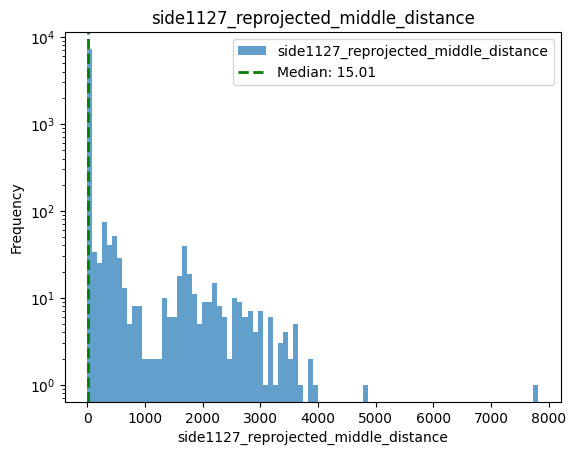

In [101]:
import matplotlib.pyplot as plt

df['side1127_reprojected_middle_distance'].plot(kind='hist', bins=90, alpha=0.7,logy=True)
plt.xlabel('side1127_reprojected_middle_distance')
plt.ylabel('Frequency')
plt.title('side1127_reprojected_middle_distance')
mean_dis = df['side1127_reprojected_middle_distance'].mean()
middle_dis = df['side1127_reprojected_middle_distance'].median()
# plt.axvline(mean_dis, color='red', linestyle='dashed', linewidth=2, label=f'Mean: {mean_dis:.2f}')
plt.axvline(middle_dis, color='green', linestyle='dashed', linewidth=2, label=f'Median: {middle_dis:.2f}')
plt.legend()
plt.show()

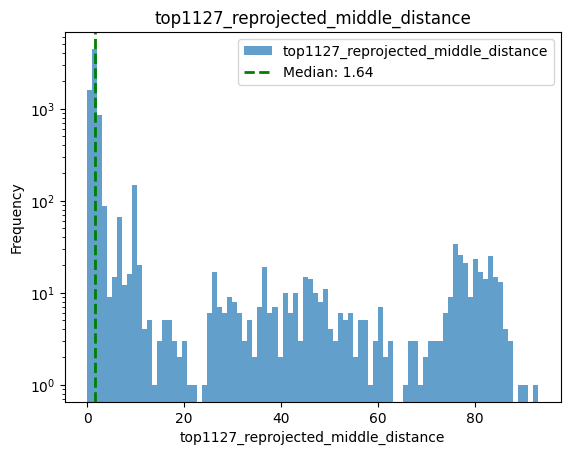

In [110]:
import matplotlib.pyplot as plt

df['top1127_reprojected_middle_distance'].plot(kind='hist', bins=90, alpha=0.7,logy=True)
plt.xlabel('top1127_reprojected_middle_distance')
plt.ylabel('Frequency')
plt.title('top1127_reprojected_middle_distance')
mean_dis = df['top1127_reprojected_middle_distance'].mean()
middle_dis = df['top1127_reprojected_middle_distance'].median()
# plt.axvline(mean_dis, color='red', linestyle='dashed', linewidth=2, label=f'Mean: {mean_dis:.2f}')
plt.axvline(middle_dis, color='green', linestyle='dashed', linewidth=2, label=f'Median: {middle_dis:.2f}')
plt.legend()
plt.show()

In [103]:
df['side1127_reprojected_middle_distance']

0       10.448091
1       10.274789
2        8.433389
3        9.021292
4        8.253749
          ...    
7834    22.857382
7835    24.673622
7836    23.949368
7837    24.248523
7838    26.435473
Name: side1127_reprojected_middle_distance, Length: 7839, dtype: float64

0       False
1       False
2       False
3        True
4       False
        ...  
2268    False
2269    False
2270    False
2271    False
2272    False
Length: 2273, dtype: bool


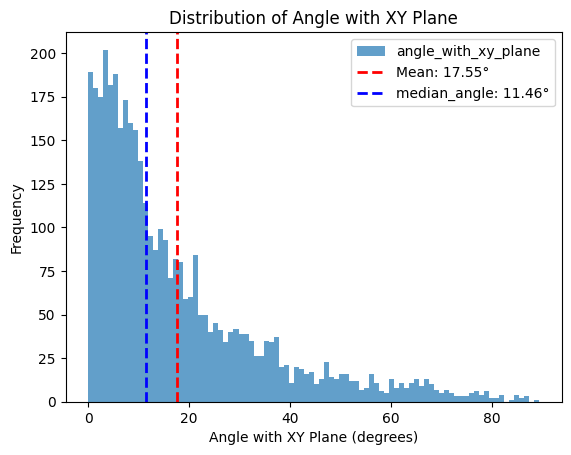

In [115]:
threshold_value =  15
valid_rows = np.bitwise_and( df['top1127_reprojected_middle_distance'] <= threshold_value, df['side1127_reprojected_middle_distance'] <= threshold_value)
df_filtered = df[valid_rows]
df_filtered['angle_with_xy_plane'].plot(kind='hist', bins=90, alpha=0.7, logy=False)
plt.xlabel('Angle with XY Plane (degrees)')
plt.ylabel('Frequency')
plt.title('Distribution of Angle with XY Plane')
mean_angle = df_filtered['angle_with_xy_plane'].mean()
median_angle = df_filtered['angle_with_xy_plane'].median()
plt.axvline(mean_angle, color='red', linestyle='dashed', linewidth=2, label=f'Mean: {mean_angle:.2f}°')
plt.axvline(median_angle, color='blue', linestyle='dashed', linewidth=2, label=f'median_angle: {median_angle:.2f}°')
plt.legend()
plt.show()


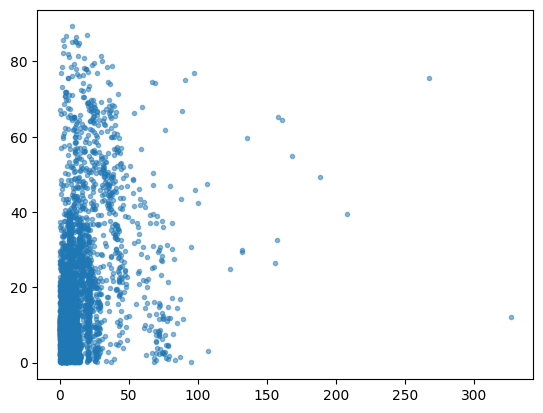

In [116]:
plt.plot(df_filtered['distance_to_line'],df_filtered['angle_with_xy_plane'],'.',alpha=0.5)